# 05 - Model Validation and Risk Segmentation

## Credit Risk Modelling Using Logistic Regression

This notebook evaluates the Stage 4 model on its reserved holdout and compares predicted Probability of Default (PD) with observed risk. Stratified cross-validation measures performance variability within the training partition. The holdout is not used to fit or select the model.

## Validation approach

**Discrimination** measures ranking: ROC-AUC, \(Gini=2AUC-1\), KS separation of predicted scores, and PR-AUC. **Calibration** compares predicted probabilities with observed event rates and includes the Brier score. Risk deciles show whether realized default rates rise across ordered PD groups.

The final 30% holdout is reconstructed using the saved split seed and scored with the Stage 4 coefficients and training-only scaling values. Five-fold stratified cross-validation is run only within the 70% training partition. Accuracy is not the primary measure for this imbalanced target.

## 1. Recreate the Stage 4 split and score the holdout

Rebuild the deterministic split using the saved seed, create the same Stage 3 features, and apply the scaler values learned on the full training partition in Stage 4. The holdout is scored once for final evaluation.

In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

sys.path.insert(0, "../src")
from model import prepare_data, split_data, predict_pd
from evaluation import discrimination_metrics, calibration_table, cross_val_auc

DATA_PATH = "../data/processed/cleaned_data.csv"
MODEL_PATH = "../models/logistic_regression.pkl"
ROC_PATH = "../reports/figures/stage5_roc.png"
CAL_PATH = "../reports/figures/stage5_calibration.png"
DEC_PATH = "../reports/figures/stage5_deciles.png"

clean_data = pd.read_csv(DATA_PATH)
feat, target = prepare_data(clean_data)
with open(MODEL_PATH, "rb") as model_file:
    model_pack = pickle.load(model_file)

train_feat, test_feat, train_y, test_y = split_data(
    feat, target, model_pack["seed"]
)
test_pd = predict_pd(test_feat, model_pack)

print(f"Training partition: {len(train_y):,} borrowers")
print(f"Reserved holdout: {len(test_y):,} borrowers")
print(f"Holdout sample default rate: {test_y.mean() * 100:.3f}%")
print(f"Holdout mean predicted PD: {test_pd.mean() * 100:.3f}%")

Training partition: 101,893 borrowers
Reserved holdout: 43,669 borrowers
Holdout sample default rate: 6.753%
Holdout mean predicted PD: 6.707%


## 2. Holdout discrimination and probability scores

ROC-AUC and Gini summarize ranking over thresholds. KS is the maximum separation between score distributions for event and non-event borrowers. PR-AUC is included because the event class is uncommon. The Brier score is the mean squared error of predicted probabilities; lower is better and it reflects both calibration and discrimination.

In [2]:
metric_vals = discrimination_metrics(test_y, test_pd)
from sklearn.metrics import brier_score_loss
base_pd = train_y.mean()
metric_vals["baseline_brier"] = brier_score_loss(
    test_y, np.full(len(test_y), base_pd)
)
metric_tab = pd.DataFrame.from_dict(
    metric_vals, orient="index", columns=["holdout_value"]
)
display(metric_tab.round(4))

,holdout_value
roc_auc,0.6532
gini,0.3064
ks,0.2325
pr_auc,0.1237
brier_score,0.0616
baseline_brier,0.0630


### ROC curve

The diagonal represents random ranking. The curve is computed from the reserved holdout predictions.

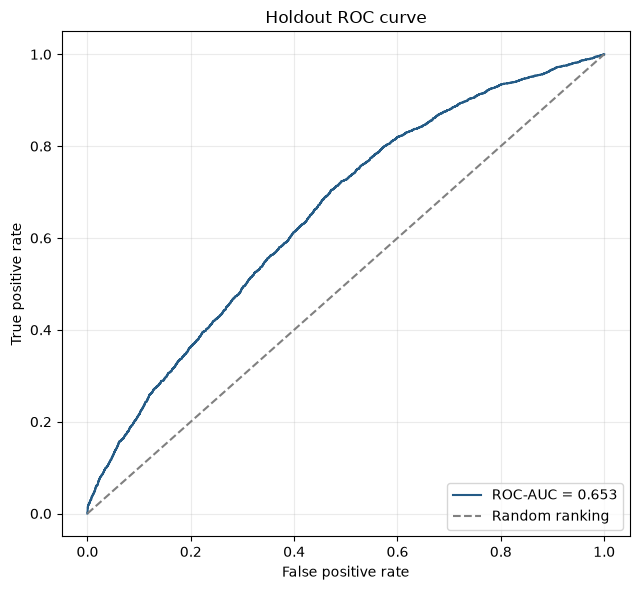

Saved ROC figure to ../reports/figures/stage5_roc.png


In [3]:
false_pos, true_pos, _ = roc_curve(test_y, test_pd)
roc_auc = metric_vals["roc_auc"]
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(false_pos, true_pos, label=f"ROC-AUC = {roc_auc:.3f}", color="#245b86")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random ranking")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Holdout ROC curve")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
fig.savefig(ROC_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved ROC figure to {ROC_PATH}")

## 3. Holdout calibration

A well-calibrated model should have a mean predicted PD close to the observed default rate within groups. Quantile bins contain approximately equal numbers of borrowers. The Brier score above gives a single probability-error summary; the curve below shows where predictions under- or over-estimate risk.

,risk_bin,borrowers,mean_predicted_pd,actual_default_rate
0,1,4367,0.0263,0.0240
1,2,4367,0.0359,0.0240
2,3,4367,0.0426,0.0373
3,4,4367,0.0491,0.0453
4,5,4367,0.0569,0.0621
5,6,4366,0.0660,0.0825
6,7,4367,0.0759,0.0804
7,8,4367,0.0870,0.0852
8,9,4367,0.1001,0.0975
9,10,4367,0.1310,0.1369


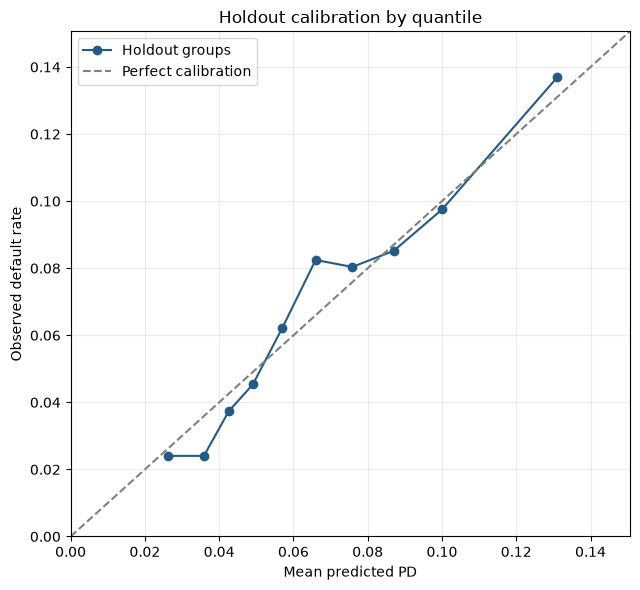

Saved calibration figure to ../reports/figures/stage5_calibration.png


In [4]:
cal_tab = calibration_table(test_y, test_pd, bins=10)
display(cal_tab.round({
    "mean_predicted_pd": 4,
    "actual_default_rate": 4,
}))
obs_rate, pred_rate = calibration_curve(
    test_y, test_pd, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(pred_rate, obs_rate, marker="o", label="Holdout groups", color="#245b86")
cal_max = max(pred_rate.max(), obs_rate.max()) * 1.1
ax.plot([0, cal_max], [0, cal_max], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlim(0, cal_max)
ax.set_ylim(0, cal_max)
ax.set_xlabel("Mean predicted PD")
ax.set_ylabel("Observed default rate")
ax.set_title("Holdout calibration by quantile")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(CAL_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved calibration figure to {CAL_PATH}")

## 4. Five-fold stratified cross-validation on training data

Each fold fits its own scaler and logistic regression using only that fold's fitting rows. ROC-AUC is measured on that fold's validation rows. These folds come only from the original training partition; the reserved holdout is not used.

In [5]:
cv_tab = cross_val_auc(
    train_feat,
    train_y,
    seed=model_pack["seed"],
    n_splits=5,
)
display(cv_tab.round(4))
cv_mean = cv_tab["roc_auc"].mean()
cv_sd = cv_tab["roc_auc"].std(ddof=1)
print(f"Mean cross-validated ROC-AUC: {cv_mean:.4f}")
print(f"SD of cross-validated ROC-AUC: {cv_sd:.4f}")

,fold,roc_auc,fit_rows,validation_rows
0,1,0.6555,81514,20379
1,2,0.6421,81514,20379
2,3,0.6409,81514,20379
3,4,0.6494,81515,20378
4,5,0.6600,81515,20378


Mean cross-validated ROC-AUC: 0.6496
SD of cross-validated ROC-AUC: 0.0083


## 5. Holdout risk deciles

Borrowers are ordered by predicted PD and divided into ten approximately equal-sized groups. Decile 1 contains the lowest predicted risk and decile 10 the highest. Compare mean predicted PD with observed default rate, and inspect any departures from monotonicity.

,decile,borrowers,mean_pd_pct,observed_rate_pct
0,1,4367,2.629,2.404
1,2,4367,3.590,2.404
2,3,4367,4.258,3.733
3,4,4367,4.906,4.534
4,5,4367,5.694,6.206
5,6,4366,6.598,8.246
6,7,4367,7.585,8.038
7,8,4367,8.702,8.518
8,9,4367,10.006,9.755
9,10,4367,13.104,13.694


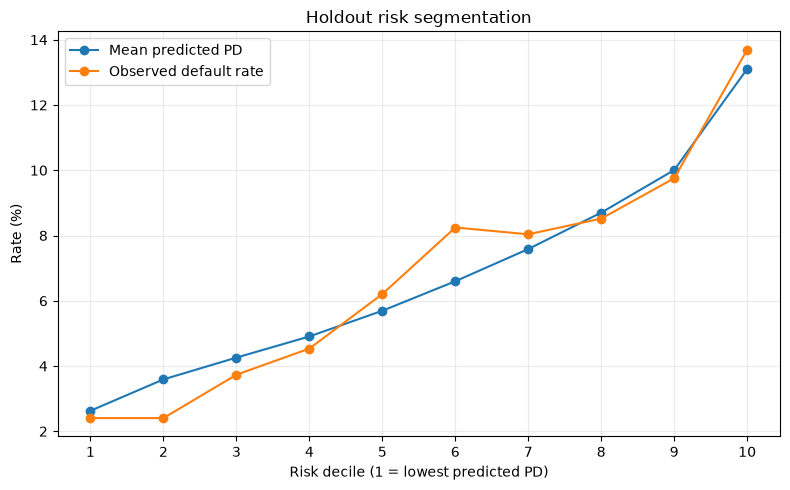

Saved decile figure to ../reports/figures/stage5_deciles.png


In [6]:
dec_tab = calibration_table(test_y, test_pd, bins=10).rename(
    columns={
        "risk_bin": "decile",
        "mean_predicted_pd": "mean_predicted_pd",
        "actual_default_rate": "actual_default_rate",
    }
)
dec_tab["mean_pd_pct"] = dec_tab["mean_predicted_pd"] * 100
dec_tab["observed_rate_pct"] = dec_tab["actual_default_rate"] * 100
display(dec_tab[[
    "decile",
    "borrowers",
    "mean_pd_pct",
    "observed_rate_pct",
]].round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dec_tab["decile"], dec_tab["mean_pd_pct"],
        marker="o", label="Mean predicted PD")
ax.plot(dec_tab["decile"], dec_tab["observed_rate_pct"],
        marker="o", label="Observed default rate")
ax.set_xticks(dec_tab["decile"])
ax.set_xlabel("Risk decile (1 = lowest predicted PD)")
ax.set_ylabel("Rate (%)")
ax.set_title("Holdout risk segmentation")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(DEC_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved decile figure to {DEC_PATH}")

## Stage 5 findings

- Holdout ROC-AUC is **0.653** (Gini **0.306**) and KS is **0.233**. Average precision (PR-AUC) is **0.124**, above the event prevalence of **0.067**.
- Five-fold stratified training ROC-AUC averages **0.650** (SD **0.008**, fold range 0.641–0.660), close to the holdout AUC of **0.653**.
- Mean predicted PD is **6.707%**, compared with a **6.753%** observed default rate. Calibration varies by group: the model overpredicts in the lower two deciles (3.59% predicted vs 2.40% observed in decile 2) and underpredicts around decile 6 (6.60% predicted vs 8.25% observed). The Brier score is **0.0616**, a modest improvement over **0.0630** for a constant prediction equal to the training default rate; interpret it alongside the calibration plot.
- Observed default rates increase from **2.40%** in the lowest decile to **13.69%** in the highest. The first two deciles tie, and the observed rate drops from **8.25%** in decile 6 to **8.04%** in decile 7. Keep these departures visible when interpreting the segmentation.
- The final holdout was scored with the Stage 4 model and training-only scaler. The five cross-validation fits each learned their own scaler within the fold. No holdout outcomes were used for fitting or model selection.

This random split of one dataset does not measure performance over time or in another borrower population. The holdout has now been used for evaluation; do not use it to select revisions. Diagnose and revise the model using training data, then use a new holdout for a further performance estimate.